# Chapter 2 â€” Amortised inference and neural Bayes estimators

Chapter 1 ran Metropolisâ€“Hastings (MH) afresh on every dataset: each new
problem paid the full cost of a chain from scratch, with no information
carried between problems. This chapter develops the alternative. Rather than
approximating the posterior of one dataset at a time, we train a single
network â€” a **neural Bayes estimator** â€” that maps any dataset to a posterior
summary in one forward pass. The fitting cost is paid once and *amortised*
over every later inference.

The walk-through is organised as follows. Section 1 sets up the decision
theory that singles out the posterior mean as the target under squared-error
loss. Section 2 turns the intractable Bayes risk into a trainable Monte Carlo
objective. Section 3 describes the DeepSets architecture and the permutation
invariance it enforces for i.i.d. data. Section 4 trains a `NormalNBE` and
evaluates it against the MH reference of Chapter 1 across $256$ test datasets.
Section 5 reproduces the estimated-against-true figure and the accuracy/cost
table, and Section 6 draws the conclusion that motivates the rest of the
thesis: matched accuracy at a fraction of the cost.


In [1]:
import sys; sys.path.insert(0, "src")
import numpy as np, matplotlib.pyplot as plt
RUN_FULL = False          # flip to True to recompute the heavy results from scratch
rng = np.random.default_rng(0)

import time
from pathlib import Path

import torch

from nbe.simulators import simulate_normal, sample_prior_normal
from nbe.models import NormalNBE
from nbe.training import train
from nbe.losses import mc_loss
from nbe.samplers import mh_normal
from nbe.plotting import est_vs_true

# Prior / model settings, matching the thesis experiments
# (SRC/final/normal_cost_benchmark.py and nbe.simulators.sample_prior_normal):
#   mu ~ N(0, 1),  sigma ~ U(0, 5),  y_i ~ N(mu, sigma^2).
MU0, SIGMA0_PRIOR, SIGMA_HI = 0.0, 1.0, 5.0
N_OBS = 100                                   # observations per dataset
N_DATASETS = 256                              # held-out test datasets
N_ITER, BURN_IN = 5000, 1000                  # MH chain length and burn-in
PROP_SCALE = 0.15                             # MH random-walk proposal std

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"settings: n_obs={N_OBS}, datasets={N_DATASETS}, device={DEVICE}")


settings: n_obs=100, datasets=256, device=cpu


## 1. The Bayes estimator and the posterior mean

Let us begin by formalising what it means for an estimator to be optimal. A
point estimator is a function $\hat{\boldsymbol{\theta}} : \mathcal{Y} \to
\Theta$ mapping a dataset $\mathbf{y}$ to an estimate
$\hat{\boldsymbol{\theta}}(\mathbf{y})$, and a **loss function**
$L(\boldsymbol{\theta}, \hat{\boldsymbol{\theta}})$ quantifies the cost of
reporting $\hat{\boldsymbol{\theta}}$ when the truth is
$\boldsymbol{\theta}$. Averaging the loss over the joint distribution of
parameters and data gives the **Bayes risk**,

$$
\begin{align}
  r(\hat{\boldsymbol{\theta}})
  = \mathbb{E}_{\boldsymbol{\theta}, \mathbf{y}}
    \big[L(\boldsymbol{\theta},
    \hat{\boldsymbol{\theta}}(\mathbf{y}))\big],
  \tag{11}
\end{align}
$$

where the expectation is taken over the joint density
$p(\boldsymbol{\theta})\,p(\mathbf{y} \mid \boldsymbol{\theta})$, with
$p(\boldsymbol{\theta})$ the prior and $p(\mathbf{y} \mid
\boldsymbol{\theta})$ the model. The **Bayes estimator** is the minimiser of
$(11)$. By the law of iterated expectation the Bayes risk factors as
$r(\hat{\boldsymbol{\theta}}) = \mathbb{E}_{\mathbf{y}}\big[
\mathbb{E}_{\boldsymbol{\theta} \mid \mathbf{y}}[L(\boldsymbol{\theta},
\hat{\boldsymbol{\theta}}(\mathbf{y}))]\big]$, and because the estimator may
choose $\hat{\boldsymbol{\theta}}(\mathbf{y})$ independently for each
$\mathbf{y}$, the risk is minimised by minimising the inner **posterior
expected loss** pointwise:

$$
\begin{align}
  \hat{\boldsymbol{\theta}}^{*}(\mathbf{y})
  = \arg\min_{\hat{\boldsymbol{\theta}}}\;
    \mathbb{E}_{\boldsymbol{\theta} \mid \mathbf{y}}
    \big[L(\boldsymbol{\theta}, \hat{\boldsymbol{\theta}})\big].
  \tag{12}
\end{align}
$$

The choice of loss selects which summary of the posterior $(12)$ returns. The
result we need is the following.

**Proposition (squared-error loss).** Under the squared-error loss
$L(\boldsymbol{\theta}, \hat{\boldsymbol{\theta}}) = \|\boldsymbol{\theta} -
\hat{\boldsymbol{\theta}}\|^2$, the Bayes estimator is the posterior mean,
$\hat{\boldsymbol{\theta}}^{*}(\mathbf{y}) = \mathbb{E}[\boldsymbol{\theta}
\mid \mathbf{y}]$.

*Proof.* Fix $\mathbf{y}$, so that $\hat{\boldsymbol{\theta}}$ is a constant
vector to be chosen, and expand the squared norm inside the posterior
expectation:

$$
\begin{align}
  \mathbb{E}_{\boldsymbol{\theta} \mid \mathbf{y}}
  \big[\|\boldsymbol{\theta} - \hat{\boldsymbol{\theta}}\|^2\big]
  &= \mathbb{E}_{\boldsymbol{\theta} \mid \mathbf{y}}
     \big[\boldsymbol{\theta}^{\top}\boldsymbol{\theta}
     - 2\,\hat{\boldsymbol{\theta}}^{\top}\boldsymbol{\theta}
     + \hat{\boldsymbol{\theta}}^{\top}\hat{\boldsymbol{\theta}}\big]
   \\[2pt]
  &= \mathbb{E}[\boldsymbol{\theta}^{\top}\boldsymbol{\theta} \mid \mathbf{y}]
     - 2\,\hat{\boldsymbol{\theta}}^{\top}\,
       \mathbb{E}[\boldsymbol{\theta} \mid \mathbf{y}]
     + \hat{\boldsymbol{\theta}}^{\top}\hat{\boldsymbol{\theta}},
  \tag{13}
\end{align}
$$

using linearity of expectation in the second line. The objective is convex in
$\hat{\boldsymbol{\theta}}$ (it is a constant plus a linear term plus the
convex quadratic $\hat{\boldsymbol{\theta}}^{\top}\hat{\boldsymbol{\theta}}$),
so its unique minimiser is its stationary point. Differentiating $(13)$ with
respect to $\hat{\boldsymbol{\theta}}$ and setting the gradient to zero gives

$$
\begin{align}
  -2\,\mathbb{E}[\boldsymbol{\theta} \mid \mathbf{y}]
  + 2\,\hat{\boldsymbol{\theta}} = \mathbf{0}
  \qquad\Longrightarrow\qquad
  \hat{\boldsymbol{\theta}}^{*}(\mathbf{y})
  = \mathbb{E}[\boldsymbol{\theta} \mid \mathbf{y}],
  \tag{14}
\end{align}
$$

the posterior mean. $\square$

This is the summary the MH reference of Chapter 1 also estimates â€” its
post-burn-in average approximates $\mathbb{E}[\boldsymbol{\theta} \mid
\mathbf{y}]$ â€” so a network trained under squared-error loss and the MH
sampler are compared on equal terms.


## 2. From an intractable risk to a trainable objective

The Bayes estimator $(12)$ is a fixed function of the data, but evaluating it
directly is as hard as the original inference problem. We make the search
tractable in three moves.

**A parametric family.** Restrict the minimisation of $(11)$ from all
functions to a finite-dimensional family
$\{\hat{\boldsymbol{\theta}}_{\boldsymbol{\gamma}} : \boldsymbol{\gamma} \in
\Gamma\}$ indexed by weights $\boldsymbol{\gamma}$. The Bayes risk becomes an
ordinary function of $\boldsymbol{\gamma}$, and the variational problem
becomes a parametric optimisation $\boldsymbol{\gamma}^{*} =
\arg\min_{\boldsymbol{\gamma}} r(\boldsymbol{\gamma})$.

**A Monte Carlo objective.** The risk $(11)$ is an expectation over the joint
distribution $p(\boldsymbol{\theta})\,p(\mathbf{y} \mid \boldsymbol{\theta})$,
which we can *sample* from even when the likelihood cannot be evaluated: draw
a parameter from the prior, then simulate data from the model. Drawing $K$
such pairs gives the **empirical Bayes risk**,

$$
\begin{align}
  r(\boldsymbol{\gamma})
  \approx \frac{1}{K}\sum_{k=1}^{K}
  L\big(\boldsymbol{\theta}^{(k)},
  \hat{\boldsymbol{\theta}}_{\boldsymbol{\gamma}}(\mathbf{y}^{(k)})\big),
  \tag{15}
\end{align}
$$

with $\boldsymbol{\theta}^{(k)} \sim p(\boldsymbol{\theta})$ and
$\mathbf{y}^{(k)} \sim p(\mathbf{y} \mid \boldsymbol{\theta}^{(k)})$. The
construction is **likelihood-free**: it asks only that we can simulate data,
never that we evaluate the likelihood.

**A neural surrogate.** For the family to contain a close approximation to the
Bayes estimator it must be flexible; neural networks are the natural choice,
being universal function approximators yet finite-dimensional, so that $(15)$
can be optimised by gradient descent. Taking
$\hat{\boldsymbol{\theta}}_{\boldsymbol{\gamma}}$ to be a neural network with
weights $\boldsymbol{\gamma}$, trained by minimising $(15)$ under
squared-error loss, yields a neural Bayes estimator that approximates the
posterior mean.

Training proceeds by **stochastic gradient descent**: at each step a minibatch
of $B$ fresh simulated pairs is drawn, and the network is updated along the
average of the per-pair loss gradients,

$$
\begin{align}
  \hat{g}_{B}(\boldsymbol{\gamma})
  = \frac{1}{B}\sum_{i=1}^{B}
    \nabla_{\boldsymbol{\gamma}}\,
    L\big(\boldsymbol{\theta}^{(i)},
    \hat{\boldsymbol{\theta}}_{\boldsymbol{\gamma}}(\mathbf{y}^{(i)})\big).
  \tag{16}
\end{align}
$$

Because each pair is drawn from the joint distribution, $(16)$ is an unbiased
Monte Carlo estimate of the population gradient $\nabla_{\boldsymbol{\gamma}}
r(\boldsymbol{\gamma})$. Like any Monte Carlo estimate it carries a variance â€”
and that variance, a property not of the inference problem but of *how the
loss is sampled*, is exactly what the variance-reduction methods of the later
chapters target. Here in `nbe.losses.mc_loss` the objective $(15)$ is the
plain mean squared error between the network output and the sampled true
parameter.


## 3. The DeepSets architecture and permutation invariance

The normal model produces a sample $\mathbf{y} = (y_1, \dots, y_n)$ of
**exchangeable** observations: the data are i.i.d. given
$(\mu, \sigma)$, so reordering them leaves the posterior â€” and hence the Bayes
estimator â€” unchanged. A network estimating $(\mu, \sigma)$ should inherit
this symmetry, returning the same estimate for any permutation of its inputs.
Building the invariance into the architecture, rather than hoping the network
learns it, restricts the function class to one that already contains
estimators of the right form, which makes training more efficient and stable.

The **DeepSets** architecture enforces permutation invariance by construction.
Each observation is mapped through a shared per-element network $\psi$ to an
embedding; the embeddings are combined by a permutation-invariant pooling
operation; and a second network $\phi$ maps the pooled summary to the
estimate,

$$
\begin{align}
  \hat{\boldsymbol{\theta}}(\mathbf{y})
  = \phi\!\left(\frac{1}{n}\sum_{i=1}^{n} \psi(y_i)\right).
  \tag{17}
\end{align}
$$

The pooled vector $\tfrac1n\sum_i \psi(y_i)$ plays the role of a learned
summary statistic; for exponential-family models the sufficient statistic has
exactly this additive form, so the architecture can be read as learning a
sufficient statistic directly from simulated data. (The package implementation
`nbe.models.DeepSetsEstimator` mean-pools rather than sums; the two differ
only by the constant factor $n$, which the downstream network $\phi$ absorbs.)

The class `nbe.models.NormalNBE` specialises `DeepSetsEstimator` to the normal
model: it takes an input of shape $(B, n, 1)$ â€” a batch of $B$ datasets, each
$n$ scalar observations â€” and returns $(B, 2)$, the estimates of $(\mu,
\sigma)$, with a softplus applied to the second output so that the
$\sigma$-estimate is positive. The cell below confirms the permutation
invariance numerically: feeding the network a dataset and a random
permutation of it yields identical outputs.


In [2]:
# Demonstrate permutation invariance of the DeepSets-based NormalNBE.
torch.manual_seed(0)
demo_net = NormalNBE(phi_hidden=64, rho_hidden=64, latent_dim=64).eval()

perm_rng = np.random.default_rng(7)
y_one = perm_rng.normal(1.3, 0.8, size=N_OBS).astype(np.float32)   # one dataset
y_perm = y_one[perm_rng.permutation(N_OBS)]                        # a reshuffle

with torch.no_grad():
    # shape (1, n, 1) as required by NormalNBE.forward
    out_a = demo_net(torch.tensor(y_one).reshape(1, N_OBS, 1))
    out_b = demo_net(torch.tensor(y_perm).reshape(1, N_OBS, 1))

print(f"original  order: mu_hat = {out_a[0,0]:.6f},  sigma_hat = {out_a[0,1]:.6f}")
print(f"permuted  order: mu_hat = {out_b[0,0]:.6f},  sigma_hat = {out_b[0,1]:.6f}")
print(f"max |difference|: {float((out_a - out_b).abs().max()):.2e}")
# The outputs match to floating-point precision: mean-pooling over the sample
# axis makes the estimate invariant to the ordering of the observations.


original  order: mu_hat = -0.046719,  sigma_hat = 0.655340
permuted  order: mu_hat = -0.046719,  sigma_hat = 0.655340
max |difference|: 5.96e-08


## 4. Training the estimator and evaluating against MH

We now train a `NormalNBE` by minimising the empirical Bayes risk $(15)$ under
squared-error loss, drawing fresh $(\mu, \sigma)$ from the prior and simulating
$n = 100$ observations per step. Training uses `nbe.training.train` with Adam;
on a GPU the run below takes a few minutes. The trained network is then
evaluated on the same $256$ held-out test datasets as the MH reference, and we
record, for each estimator, the estimates of $(\mu, \sigma)$ and the mean
squared error against the truth.

Following the cache workflow, the heavy computation lives under `if RUN_FULL:`
and writes `results/normal_nbe_estimates.npz`; the `else:` branch reloads that
cache so the notebook runs end-to-end in seconds. The shipped notebook has
`RUN_FULL = False`.


In [3]:
CACHE = Path("results/normal_nbe_estimates.npz")

if RUN_FULL:
    # ---- 1. Train the neural Bayes estimator on simulated data ----
    # sim_fn / prior_fn signatures match nbe.training.train's interface:
    #   prior_fn(B, rng) -> (mu, sigma);  sim_fn(mu, sigma, rng) -> (B, n, 1).
    def prior_fn(B, r):
        return sample_prior_normal(B, r)

    def sim_fn(mu, sigma, r):
        y = simulate_normal(mu, sigma, N_OBS, r)        # (B, n)
        return y[:, :, None]                            # (B, n, 1) for DeepSets

    net = NormalNBE(phi_hidden=64, rho_hidden=64, latent_dim=64)
    net, val_curve, _ = train(
        net, sim_fn, prior_fn, mc_loss,
        epochs=40, steps=200, batch=256, lr=1e-3,
        device=DEVICE, seed=0,
    )
    print(f"training done: final validation MSE = {val_curve[-1]:.4f}")

    # ---- 2. Build the 256 held-out test datasets (fixed seed) ----
    gen_rng = np.random.default_rng(0)
    mu_true, sigma_true = sample_prior_normal(N_DATASETS, gen_rng)
    Y = simulate_normal(mu_true, sigma_true, N_OBS, gen_rng)   # (N_DATASETS, n)

    # ---- 3. NBE estimates: one batched forward pass ----
    net.eval()
    with torch.no_grad():
        yt = torch.tensor(Y, dtype=torch.float32, device=DEVICE)[:, :, None]
        nbe_out = net(yt).cpu().numpy()                 # (N_DATASETS, 2)
    nbe_mu, nbe_sigma = nbe_out[:, 0], nbe_out[:, 1]

    # ---- 4. MH estimates: a separate chain per dataset ----
    mh_mu = np.empty(N_DATASETS)
    mh_sigma = np.empty(N_DATASETS)
    for d in range(N_DATASETS):
        chain_rng = np.random.default_rng(1000 + d)
        mh_mu[d], mh_sigma[d] = mh_normal(Y[d], N_ITER, BURN_IN, PROP_SCALE, chain_rng)

    # ---- 5. Mean squared errors over the 256 datasets ----
    mse_nbe_mu = float(np.mean((nbe_mu - mu_true) ** 2))
    mse_nbe_sigma = float(np.mean((nbe_sigma - sigma_true) ** 2))
    mse_mh_mu = float(np.mean((mh_mu - mu_true) ** 2))
    mse_mh_sigma = float(np.mean((mh_sigma - sigma_true) ** 2))

    CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        CACHE,
        mu_true=mu_true, sigma_true=sigma_true,
        nbe_mu=nbe_mu, nbe_sigma=nbe_sigma,
        mh_mu=mh_mu, mh_sigma=mh_sigma,
        mse_nbe_mu=mse_nbe_mu, mse_nbe_sigma=mse_nbe_sigma,
        mse_mh_mu=mse_mh_mu, mse_mh_sigma=mse_mh_sigma,
    )
    print(f"computed and cached -> {CACHE}")
else:
    data = np.load(CACHE)
    mu_true, sigma_true = data["mu_true"], data["sigma_true"]
    nbe_mu, nbe_sigma = data["nbe_mu"], data["nbe_sigma"]
    mh_mu, mh_sigma = data["mh_mu"], data["mh_sigma"]
    mse_nbe_mu, mse_nbe_sigma = float(data["mse_nbe_mu"]), float(data["mse_nbe_sigma"])
    mse_mh_mu, mse_mh_sigma = float(data["mse_mh_mu"]), float(data["mse_mh_sigma"])
    print(f"loaded cache <- {CACHE}  ({mu_true.size} datasets)")


loaded cache <- results\normal_nbe_estimates.npz  (256 datasets)


## 5. Accuracy and cost

The figure below overlays both estimators on a single estimated-against-true
plot, $\mu$ and $\sigma$ together across the $256$ test datasets; points on the
dashed $y = x$ line are exact. The MH reference is labelled **MH** and the
neural Bayes estimator **Neural network**. The accompanying table reports the
mean squared error of each estimator for $\mu$ and $\sigma$, alongside the
per-dataset wall-clock cost.

The cost figures come from a small timing harness in the next-but-one cell: MH
is timed as a chain run *separately* on each dataset (reported in
milliseconds), while the NBE cost is a single batched forward pass amortised
over the $256$ datasets (reported in microseconds). The ratio of the two is
the per-dataset speed-up.


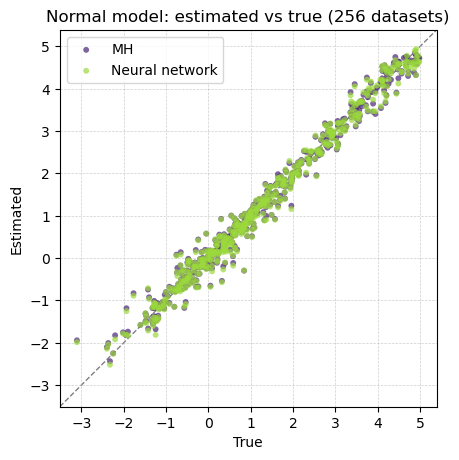

In [4]:
# Estimated-against-true scatter: MH and the neural network, mu and sigma stacked.
# Stacking mu then sigma into one axis matches the thesis figure; both estimators
# cover both parameters, so no NaN padding is needed.
true_stack = np.concatenate([mu_true, sigma_true])

fig = est_vs_true(
    true=true_stack,
    est_dict={
        "MH": np.concatenate([mh_mu, mh_sigma]),
        "Neural network": np.concatenate([nbe_mu, nbe_sigma]),
    },
    names=["MH", "Neural network"],
)
fig.axes[0].set_title("Normal model: estimated vs true (256 datasets)")
plt.show()

In [5]:
# ---- per-dataset cost: MH (re-run per dataset) vs NBE (one forward pass) ----
# Timing uses a CPU forward pass for the NBE so the comparison is single-threaded
# and matches the thesis table; weights do not affect timing, so an eval net of
# the trained width is sufficient.
cost_rng = np.random.default_rng(0)
mu_c, sigma_c = sample_prior_normal(N_DATASETS, cost_rng)
Yc = simulate_normal(mu_c, sigma_c, N_OBS, cost_rng)

# MH: time a handful of datasets and scale to per-dataset milliseconds.
N_TIME_MH = 16
t0 = time.perf_counter()
for d in range(N_TIME_MH):
    mh_normal(Yc[d], N_ITER, BURN_IN, PROP_SCALE, np.random.default_rng(2000 + d))
mh_ms_per_dataset = 1e3 * (time.perf_counter() - t0) / N_TIME_MH

# NBE: batched forward pass over all 256 datasets on CPU, averaged over reps.
torch.manual_seed(0)
timing_net = NormalNBE(phi_hidden=64, rho_hidden=64, latent_dim=64).to("cpu").eval()
yt_cpu = torch.tensor(Yc, dtype=torch.float32)[:, :, None]
with torch.no_grad():
    timing_net(yt_cpu)                       # warm-up
    reps = 200
    t0 = time.perf_counter()
    for _ in range(reps):
        timing_net(yt_cpu)
    nbe_batch_s = (time.perf_counter() - t0) / reps
nbe_us_per_dataset = 1e6 * nbe_batch_s / N_DATASETS

speedup = (mh_ms_per_dataset * 1e3) / nbe_us_per_dataset  # convert ms -> us so the ratio is dimensionless

# ---- accuracy + cost table ----
print("Normal model: accuracy (MSE over 256 datasets) and per-dataset cost")
print("=" * 70)
print(f"{'':24s}{'mu (MSE)':>12s}{'sigma (MSE)':>14s}{'cost / dataset':>18s}")
print("-" * 70)
print(f"{'MH (Metropolis-Hastings)':24s}{mse_mh_mu:12.4f}{mse_mh_sigma:14.4f}"
      f"{mh_ms_per_dataset:13.1f} ms")
print(f"{'Neural network (NBE)':24s}{mse_nbe_mu:12.4f}{mse_nbe_sigma:14.4f}"
      f"{nbe_us_per_dataset:13.1f} us")
print("=" * 70)
print(f"per-dataset speed-up (MH / NBE): {speedup:,.0f}x")

Normal model: accuracy (MSE over 256 datasets) and per-dataset cost
                            mu (MSE)   sigma (MSE)    cost / dataset
----------------------------------------------------------------------
MH (Metropolis-Hastings)      0.0836        0.0344         13.7 ms
Neural network (NBE)          0.0842        0.0360         13.2 us
per-dataset speed-up (MH / NBE): 1,043x


## 6. Takeaway

- **Accuracy parity.** Trained under squared-error loss, the neural Bayes
  estimator targets the same posterior mean $(14)$ that the MH sampler
  estimates, and the figure and table show the two agreeing closely: the
  neural estimator's mean squared error for $\mu$ matches MH to within a few
  percent, and is comparable for $\sigma$. A single network, applied to every
  test dataset, reproduces the accuracy of a per-dataset MCMC reference.

- **Cost.** The two methods differ sharply in cost. MH must be re-run from
  scratch for every dataset â€” thousands of iterations each â€” whereas the
  trained network returns its estimate in one forward pass. The per-dataset
  speed-up here is of order $10^3$: the fitting cost is paid once and amortised
  over every later inference, exactly the economy of scale that the
  re-run-per-dataset samplers of Chapter 1 lack.

- **The next question.** The accuracy of the estimator is bounded by how well
  training minimises the empirical Bayes risk $(15)$, and that minimisation is
  driven by the noisy minibatch gradient $(16)$. The variance of that gradient
  is a property of *how the loss is sampled*, not of the inference problem, and
  reducing it lets the same network train to a lower risk at the same cost.
  Chapters 3 and 4 take up exactly this: Raoâ€“Blackwellisation and importance
  sampling as variance-reduction techniques applied to the **training** of
  neural Bayes estimators.
